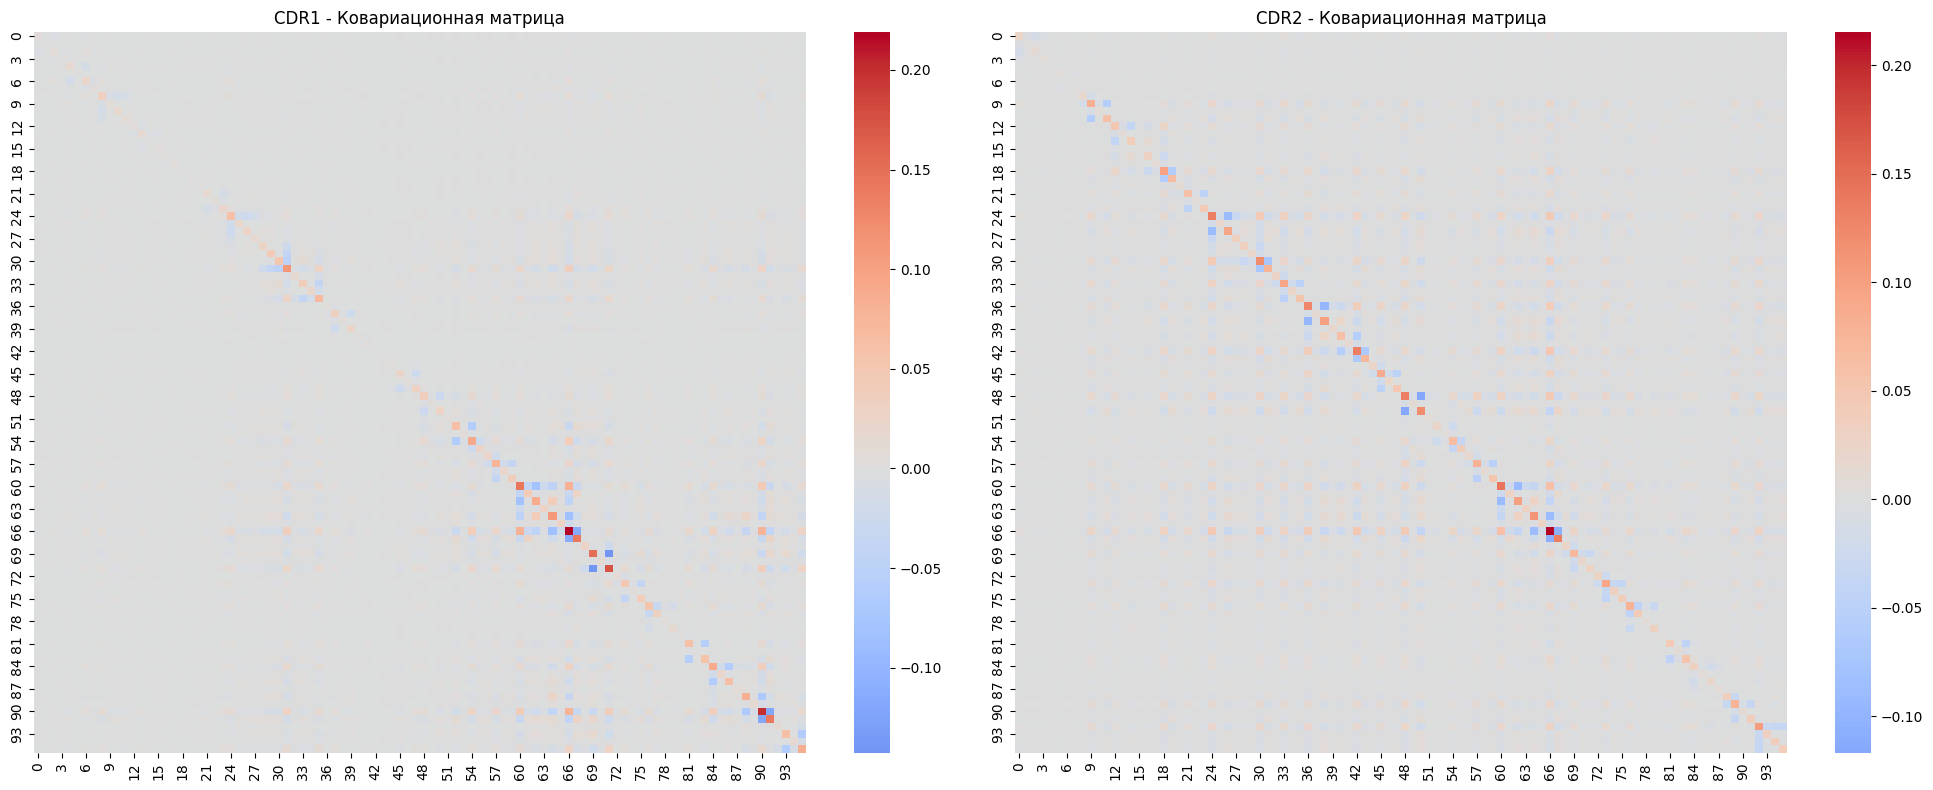

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/veronikaaksinina/Downloads/all_ighv3-21_cdr_data.csv")
cdr1 = df.iloc[:, 0].dropna().astype(str)
cdr2 = df.iloc[:, 2].dropna().astype(str)

def calculate_covariance_matrix(sequences):
    seq_len = len(sequences.iloc[0])
    
    one_hot_data = []
    for seq in sequences:
        if len(seq) == seq_len:
            encoded_seq = []
            for pos in range(seq_len):
                for nt in ['A','T','G','C']:
                    encoded_seq.append(1 if seq[pos] == nt else 0)
            one_hot_data.append(encoded_seq)
    
    cov_matrix = np.cov(np.array(one_hot_data).T)
    return cov_matrix

cdr1_cov = calculate_covariance_matrix(cdr1)
cdr2_cov = calculate_covariance_matrix(cdr2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cdr1_cov, ax=ax1, cmap='coolwarm', center=0)
ax1.set_title('CDR1 - Ковариационная матрица')

sns.heatmap(cdr2_cov, ax=ax2, cmap='coolwarm', center=0)
ax2.set_title('CDR2 - Ковариационная матрица')

plt.tight_layout()
plt.show()